In [1]:
import os
import re
import pandas as pd
import plotnine as pln

# helper functions

In [2]:
def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation)
    if parts:
        wt, site, mut = parts.groups()
        return [wt, int(site), mut]
    else:
        return [None, None, None]
    
split_mut_sit('H2T')

['H', 2, 'T']

In [3]:
def annotation_df(res, target, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['R2_score_test'].corr(res.query(q)[target], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df[target] = x
    ann_df['R2_score_test'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df

In [4]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

# Computing variability metrics

## Relative variability of site means

In [5]:
# Relative variability of site means
res_dict = {'source':[], 'Dataset':[], 'RVSM':[]}
for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
      
        data = pd.read_csv(f'../data/{source}/metadata/{file}')
        data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
        
        # equation
        total_std = data['target'].std()
        grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].mean()
        sd_sites = grouped_data['target'].std()
        variance = sd_sites / total_std


        res_dict['source'].append(source)
        res_dict['Dataset'].append(file.replace('.csv', ''))
        res_dict['RVSM'].append(variance)

RVSM = pd.DataFrame.from_dict(res_dict)
RVSM['source'] = pd.Categorical(RVSM['source'], categories=['viral', 'cellular'])
RVSM

,source,Dataset,RVSM
0,cellular,TIM_THETH,0.707607
1,cellular,TIM_THEMA,0.667472
2,cellular,MK01_HUMAN_Johannessen,0.501967
3,cellular,IF1_ECOLI,0.716184
4,cellular,TIM_SULSO,0.679531
...,...,...,...
69,viral,CVB3_2A_Alvarez,0.776574
70,viral,CVB3_3A_Alvarez,0.648906
71,viral,SARS2_PLPRO_activity_Wu,0.817721
72,viral,SARS2_BA1_SPIKE_Dadonaite,0.682066


In [6]:
RVSM_dict = {}
for idx, col in RVSM.iterrows():
    RVSM_dict[col['Dataset']] = col['RVSM']

## Fraction of highly variable sites

In [7]:
cutoff = 0.7
res_dict = {'source':[], 'Dataset':[], 'fraction':[]}
for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
        data = pd.read_csv(f'../data/{source}/metadata/{file}')
        data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
        
        grouped_data = data.groupby('site', as_index=False, observed=True)['target'].std()#.fillna(0)
        
        global_std = data['target'].std()
        grouped_data['frac_std'] = grouped_data['target'] / global_std
        sites = list(grouped_data.query(f'frac_std > {cutoff}')['site'].values)
        data = data.query('site in @sites')
        fraction = len(sites)/grouped_data.shape[0] # frac=part/total

        res_dict['source'].append(source)
        res_dict['Dataset'].append(file.replace('.csv', ''))
        res_dict['fraction'].append(fraction)

FHVS = pd.DataFrame.from_dict(res_dict)
FHVS['source'] = pd.Categorical(FHVS['source'], categories=['viral', 'cellular'])
FHVS

,source,Dataset,fraction
0,cellular,TIM_THETH,0.475000
1,cellular,TIM_THEMA,0.425000
2,cellular,MK01_HUMAN_Johannessen,0.777159
3,cellular,IF1_ECOLI,0.305556
4,cellular,TIM_SULSO,0.537500
...,...,...,...
69,viral,CVB3_2A_Alvarez,0.366667
70,viral,CVB3_3A_Alvarez,0.674157
71,viral,SARS2_PLPRO_activity_Wu,0.295238
72,viral,SARS2_BA1_SPIKE_Dadonaite,0.582066


In [8]:
FHVS_dict = {}
for idx, col in FHVS.iterrows():
    FHVS_dict[col['Dataset']] = col['fraction']

## Coverage

In [ ]:
# load viral metadata and calculate coverage
coverage = []
dataset = []
sources = []

for source in ['cellular', 'viral']:
    mtda_dir = f"../data/{source}/metadata" 
    for file in os.listdir(mtda_dir):
        filename = file.removesuffix('.csv')

        mtda = pd.read_csv(os.path.join(mtda_dir, file))
        mtda = mtda.query("mutant != 'WT'")
        mtda[['wt', 'site', 'mut']] = mtda['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
        
        # Equation
        site_sum = mtda.groupby('site').size().sum()
        seq_len = len(mtda["sequence"][0])
        cov = site_sum / (seq_len * 20)
        
        # append results
        coverage.append(cov)
        dataset.append(filename)
        sources.append(source)


cov = pd.DataFrame({"Dataset": dataset, "Coverage": coverage, "Source":sources})
cov['Source'] = pd.Categorical(cov['Source'], categories=['viral', 'cellular'])
cov

,Dataset,Coverage,Source
0,TIM_THETH,0.299016,cellular
1,TIM_THEMA,0.301389,cellular
2,MK01_HUMAN_Johannessen,0.945694,cellular
3,IF1_ECOLI,0.999306,cellular
4,TIM_SULSO,0.306250,cellular
...,...,...,...
69,CVB3_2A_Alvarez,0.997333,viral
70,CVB3_3A_Alvarez,0.994382,viral
71,SARS2_PLPRO_activity_Wu,0.844146,viral
72,SARS2_BA1_SPIKE_Dadonaite,0.432266,viral


In [10]:
cov_dict = {}
for idx, col in cov.iterrows():
    cov_dict[col['Dataset']] = col['Coverage']

## protein length

In [11]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

## Results Lasso

In [35]:
cols = ['R2_score_train', 'MAE_score_train', 'RMSE_score_train','rho_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_test', 'num_nonzero_coefs']

model = 'esm2_650M'

lassocv = pd.DataFrame()
for source in ['viral', 'cellular']:
    for method in ['pool_split', 'site_split']:
        res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
        res = read_results(res_dir_path, model)
        res['Source'] = source
        res['Split'] = method
        
        lassocv = pd.concat([lassocv, res], ignore_index=True)

rename_map = {
    'esm2_650M':'ESM-2 650M',
    'pool_split':'Pooled Split',
    'site_split':'Site Split',
    }

lassocv.replace(rename_map, inplace=True)
lassocv = lassocv.groupby(['Model', 'Source', 'Dataset', 'Split'], as_index=False)[cols].mean()
lassocv

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs
0,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.593274,0.473718,0.637422,0.794904,0.486188,0.525113,0.717140,0.738094,444.8
1,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.374695,0.604338,0.795778,0.647042,0.231793,0.647925,0.845461,0.504309,79.6
2,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.556010,0.529118,0.665334,0.764524,0.468531,0.579832,0.733204,0.713379,590.4
3,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.362078,0.643427,0.798541,0.642935,0.243568,0.700345,0.868268,0.545077,89.6
4,ESM-2 650M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.360828,0.607812,0.800282,0.562654,0.256701,0.650875,0.857956,0.474479,533.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,ESM-2 650M,viral,SARS2_RBD_binding_Starr,Site Split,0.238382,0.650661,0.870498,0.389841,0.033222,0.719386,0.968608,0.200680,34.4
144,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.729695,0.409088,0.520078,0.843533,0.574433,0.506460,0.650963,0.751288,562.6
145,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Site Split,0.120889,0.818213,0.930678,0.289695,0.034882,0.875149,0.999084,0.193756,16.4
146,ESM-2 650M,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.666417,0.440333,0.577750,0.693423,-0.196764,0.541360,1.001461,0.610699,454.0


# Compiling results

In [36]:
lassocv['RVSM'] = lassocv['Dataset'].map(RVSM_dict)
lassocv['FHVS'] = lassocv['Dataset'].map(FHVS_dict)
lassocv['coverage'] = lassocv['Dataset'].map(cov_dict)
lassocv['prot_length'] = lassocv['Dataset'].map(prot_lengths)

lassocv['Source'] = pd.Categorical(lassocv['Source'], categories=['viral', 'cellular'])

lassocv

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,RVSM,FHVS,coverage,prot_length
0,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.593274,0.473718,0.637422,0.794904,0.486188,0.525113,0.717140,0.738094,444.8,0.684369,0.504399,0.949133,346
1,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.374695,0.604338,0.795778,0.647042,0.231793,0.647925,0.845461,0.504309,79.6,0.684369,0.504399,0.949133,346
2,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.556010,0.529118,0.665334,0.764524,0.468531,0.579832,0.733204,0.713379,590.4,0.596003,0.660592,0.948633,439
3,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.362078,0.643427,0.798541,0.642935,0.243568,0.700345,0.868268,0.545077,89.6,0.596003,0.660592,0.948633,439
4,ESM-2 650M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.360828,0.607812,0.800282,0.562654,0.256701,0.650875,0.857956,0.474479,533.0,0.513957,0.749431,0.918793,439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,ESM-2 650M,viral,SARS2_RBD_binding_Starr,Site Split,0.238382,0.650661,0.870498,0.389841,0.033222,0.719386,0.968608,0.200680,34.4,0.828026,0.263682,0.149332,1273
144,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.729695,0.409088,0.520078,0.843533,0.574433,0.506460,0.650963,0.751288,562.6,0.857385,0.194030,0.149175,1273
145,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Site Split,0.120889,0.818213,0.930678,0.289695,0.034882,0.875149,0.999084,0.193756,16.4,0.857385,0.194030,0.149175,1273
146,ESM-2 650M,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.666417,0.440333,0.577750,0.693423,-0.196764,0.541360,1.001461,0.610699,454.0,0.819106,0.308458,0.999751,201


In [37]:
#lassocv.to_csv('../experiments/compiled_results/res_lassoCV_esm2_650m_all_metrics.csv')

# Plotting Results

In [8]:
lassocv = pd.read_csv('../experiments/compiled_results/res_lassoCV_esm2_650m_all_metrics.csv', index_col=0)

res = lassocv.query('Split == "Pooled Split"').copy()
res['Source'] = pd.Categorical(res['Source'], categories=['viral', 'cellular'])
res

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,RVSM,FHVS,coverage,prot_length
0,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.593274,0.473718,0.637422,0.794904,0.486188,0.525113,0.717140,0.738094,444.8,0.684369,0.504399,0.949133,346
2,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.556010,0.529118,0.665334,0.764524,0.468531,0.579832,0.733204,0.713379,590.4,0.596003,0.660592,0.948633,439
4,ESM-2 650M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.360828,0.607812,0.800282,0.562654,0.256701,0.650875,0.857956,0.474479,533.0,0.513957,0.749431,0.918793,439
6,ESM-2 650M,cellular,BG_STRSQ_hmmerbit,Pooled Split,0.609863,0.466085,0.623503,0.752856,0.427510,0.557889,0.761146,0.657100,357.2,0.600783,0.526946,0.349301,501
8,ESM-2 650M,cellular,BLAT_ECOLX_Ostermeier2014,Pooled Split,0.721392,0.415068,0.527552,0.862508,0.666155,0.453597,0.578243,0.834210,414.2,0.745130,0.412587,0.955944,286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,ESM-2 650M,viral,SARS2_PLPRO_activity_Wu,Pooled Split,0.568696,0.542237,0.657851,0.738479,0.476946,0.587562,0.717863,0.670703,357.8,0.817721,0.295238,0.844146,316
140,ESM-2 650M,viral,SARS2_PRD0038_RBD_Starr,Pooled Split,0.585161,0.467548,0.644816,0.616855,0.470560,0.509222,0.722949,0.561168,261.4,0.806632,0.300000,0.999500,200
142,ESM-2 650M,viral,SARS2_RBD_binding_Starr,Pooled Split,0.675776,0.409628,0.565875,0.702333,0.578545,0.475782,0.664044,0.650842,436.8,0.828026,0.263682,0.149332,1273
144,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.729695,0.409088,0.520078,0.843533,0.574433,0.506460,0.650963,0.751288,562.6,0.857385,0.194030,0.149175,1273


# Variation across site

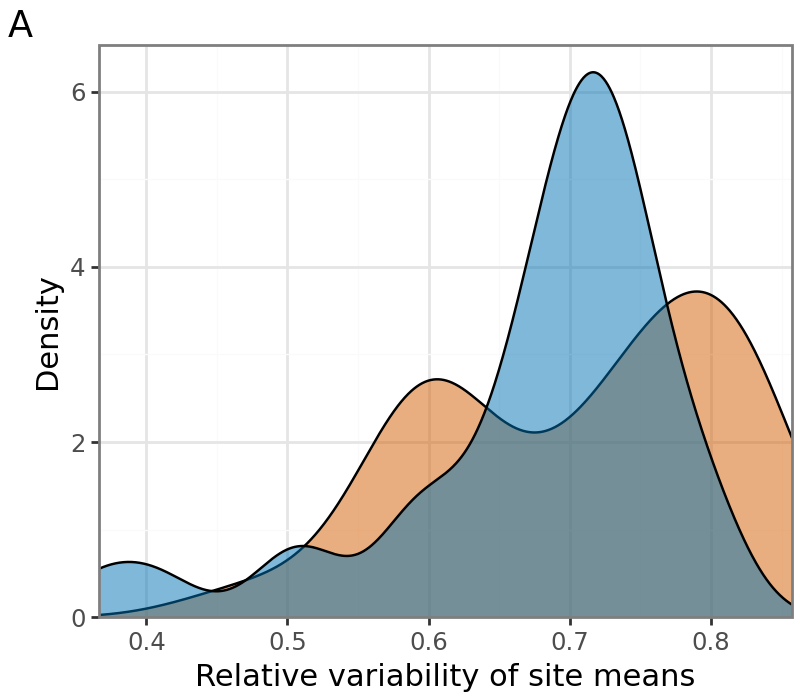

In [39]:
p1 = (
    pln.ggplot(res, pln.aes(x='RVSM', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Relative variability of site means',
        y='Density',
        tag='A')
    + pln.theme(
        legend_position='none',
        figure_size=(4, 3.5))
    )

p1

# Variation within site

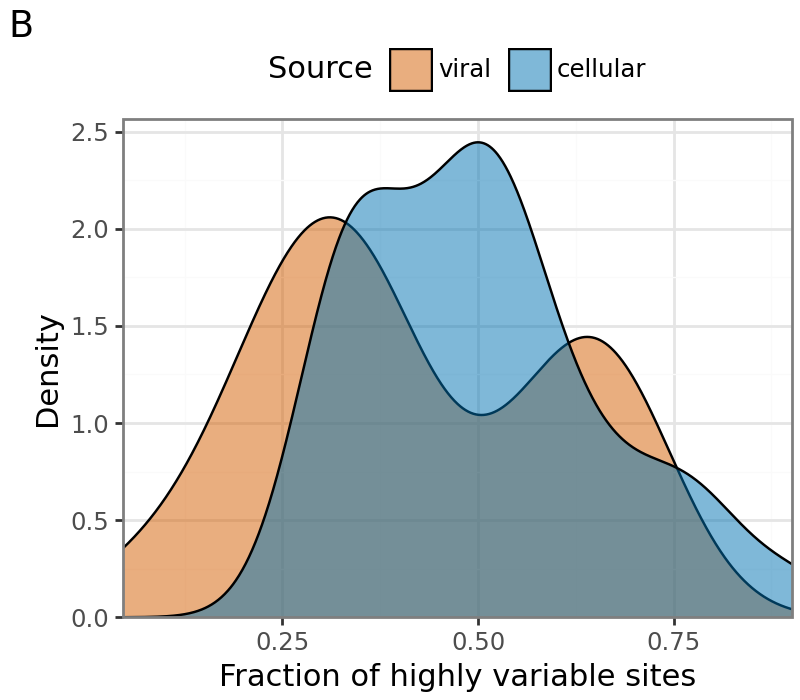

In [40]:
p2 = (
    pln.ggplot(res, pln.aes(x='FHVS', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Fraction of highly variable sites',
        y='Density',
        tag='B')
    + pln.theme(
        legend_position='top',
        figure_size=(4, 3.5))
    )

p2

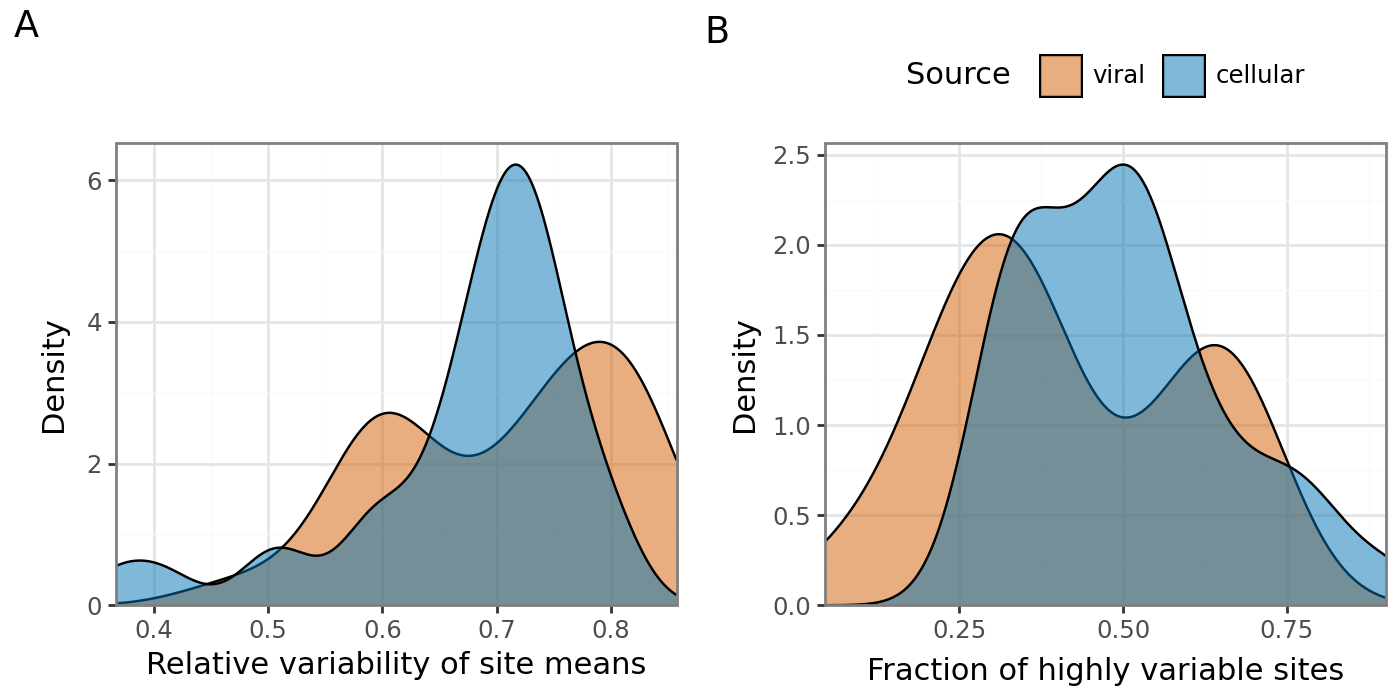

In [20]:
comp = p1 | p2
plot = comp + pln.theme(figure_size=(7, 3.5))
#plot.save(filename='../experiments/figures/supp2_site_variation_density.png', dpi=600)
plot

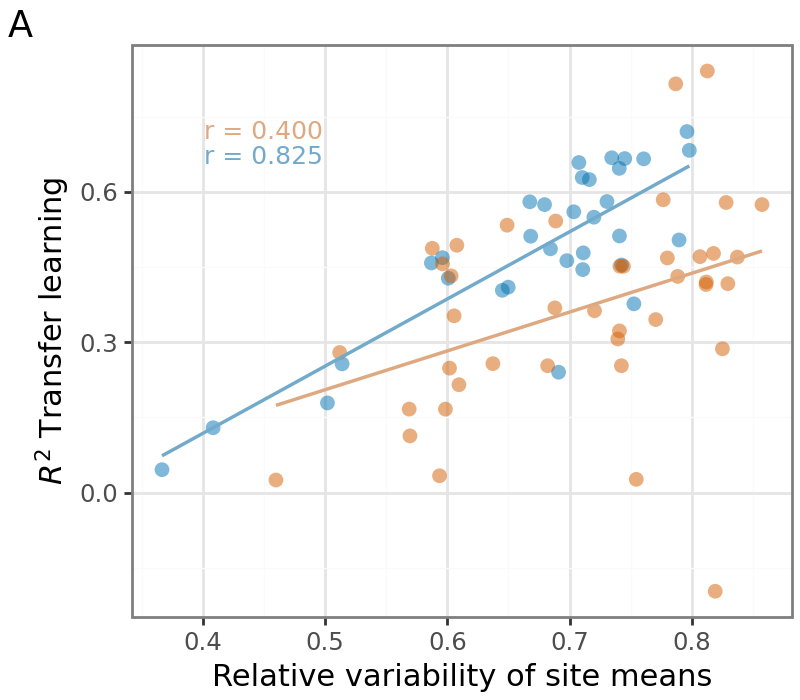

In [9]:
target = 'RVSM'
ann_df = annotation_df(res, target,  x=0.401, y=0.67)
ann_df = ann_df.query('Split == "Pooled Split"')

p3 = (
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.geom_text(data= ann_df , mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='none', figure_size=(4, 3.5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Relative variability of site means',
        tag='A')
    )

p3

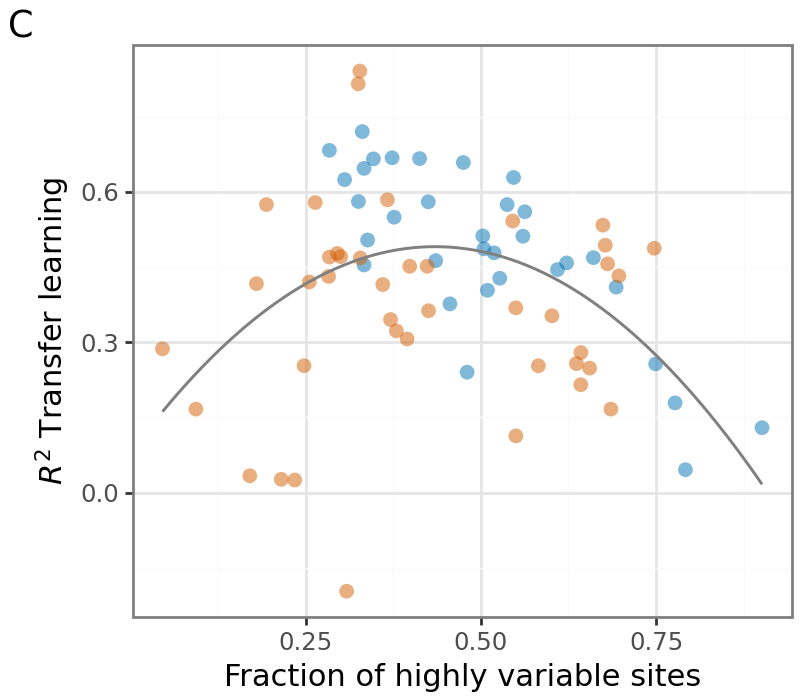

In [10]:
p5 = (
    pln.ggplot(res, pln.aes(x='FHVS', y='R2_score_test'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0, mapping=pln.aes(fill='Source'))
 
    + pln.geom_smooth(
        method='lm',
        formula='y ~ I(x*x) + x',
        se=False, alpha=1, size=0.6, color='grey'
      )
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.theme_bw()
    + pln.theme(
        legend_position='none', 
        figure_size=(4, 3.5)
        )
    
    + pln.labs(
        y='$R^2$ Transfer learning',
        x = 'Fraction of highly variable sites',
        tag='C'
      )
    )

p5

# Correlation between variation within and across sites

In [11]:
def annotation_corr(res, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['RVSM'].corr(res.query(q)['FHVS'], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df['FHVS'] = x
    ann_df['RVSM'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df



ann_df = annotation_corr(res, x=0.7, y=0.77)
ann_df = ann_df.query('Split == "Pooled Split"')
ann_df

,Source,Split,correlation,label,FHVS,RVSM
0,viral,Pooled Split,-0.603715,r = -0.604,0.7,0.82
2,cellular,Pooled Split,-0.878519,r = -0.879,0.7,0.77


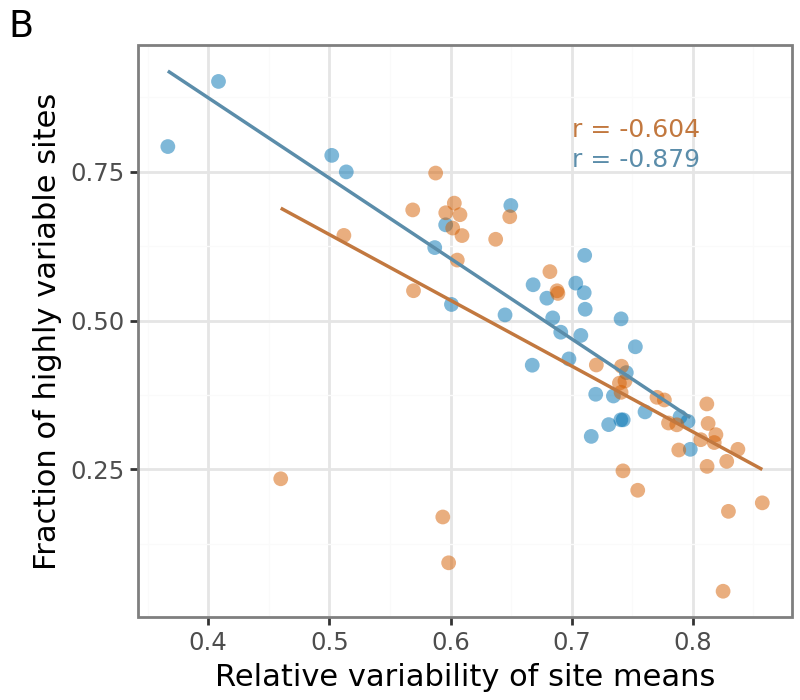

In [12]:
p4 = (
    pln.ggplot(res, pln.aes(x='RVSM', y='FHVS', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.theme_bw()
    + pln.geom_text(data=ann_df, mapping=pln.aes(x='FHVS', y='RVSM', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.labs(
        y='Fraction of highly variable sites',
        x='Relative variability of site means',
        tag='B'
        )
    + pln.theme(
        legend_position='none',
        figure_size=(4, 3.5))
        )

p4

# Transfer leanring vs AVG

In [5]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [6]:
def load_results(lassoCV_res_dir, AVG_res_dir):
    lassoCV = pd.DataFrame()
    for model in ['esm2_650m']:
        for source in ['viral', 'cellular']:
            for method in ['pool_split']:
                res_dir_path = f'{lassoCV_res_dir}/{model}/{source}/{method}/'
                res = read_results(res_dir_path, 'ESM-2 650M')
                res['Source'] = source
                res['Split'] = method
                res['Model'] = model
                
                lassoCV = pd.concat([lassoCV, res], ignore_index=True)

    res_avg = pd.DataFrame()
    for source in ['viral', 'cellular']:
        for method in ['pool_split']:
            res_dir_path = f'{AVG_res_dir}/{source}/{method}/'
            res = read_results(res_dir_path, 'AVG')
            res['Source'] = source
            res['Split'] = method
            res_avg = pd.concat([res_avg, res], ignore_index=True)


    res = pd.concat([res_avg, lassoCV.drop('num_nonzero_coefs', axis=1)])
    res = res.groupby(['Model', 'Dataset', 'Source', 'Split'], as_index=False).mean()
    res = res.query('Split == "pool_split"')

    res_pivot = pd.pivot_table(res, index=['Dataset', 'Source', 'Split'], columns='Model', values='R2_score_test').reset_index()

    return res_pivot 

In [ ]:
resSTD07 = load_results('../experiments/lassoCV_STD0.7_filtered', '../experiments/AVG_STD0.7_filtered/')
resSTD07['Source'] = pd.Categorical(resSTD07['Source'], categories=['viral', 'cellular'])
resSTD07 = resSTD07.rename(columns={"AVG":"R2_AVG_HVS", "esm2_650m":"R2_ESM2_650M_HVS"})
resSTD07

Model,Dataset,Source,Split,AVG,esm2_650m
0,AMIE_PSEAE_Whitehead,cellular,pool_split,0.134296,0.386383
1,B3VI55_LIPSTSTABLE,cellular,pool_split,0.082952,0.419996
2,B3VI55_LIPST_Whitehead2015,cellular,pool_split,0.153133,0.270976
3,BG_STRSQ_hmmerbit,cellular,pool_split,-0.220095,0.338162
4,BLAT_ECOLX_Ostermeier2014,cellular,pool_split,0.208279,0.619015
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,pool_split,-0.020813,0.093492
70,TPMT_HUMAN_Fowler2018,cellular,pool_split,0.172461,0.408743
71,UBC9_HUMAN_Roth2017,cellular,pool_split,0.126850,0.286254
72,UBE4B_MOUSE_Klevit2013_singles,cellular,pool_split,-0.119632,0.171876


In [ ]:
#resSTD07.to_csv('../experiments/compiled_results/res_lassoCV_x_AVG_HVS.csv')

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


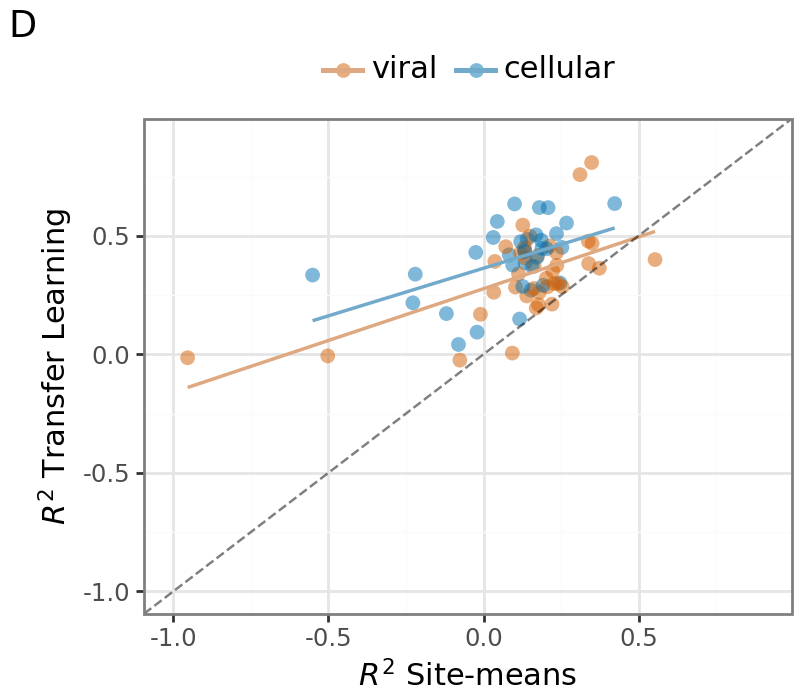

In [14]:
p6 = (
    pln.ggplot(resSTD07, pln.aes(y='R2_ESM2_650M_HVS', x='R2_AVG_HVS', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(4,3.5),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.ylim(-1, 0.9)
    + pln.xlim(-1, 0.9)
    + pln.labs(
        y="$R^2$ Transfer Learning",
        x="$R^2$ Site-means",
        tag='D'
    )
    )
p6

# composition

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


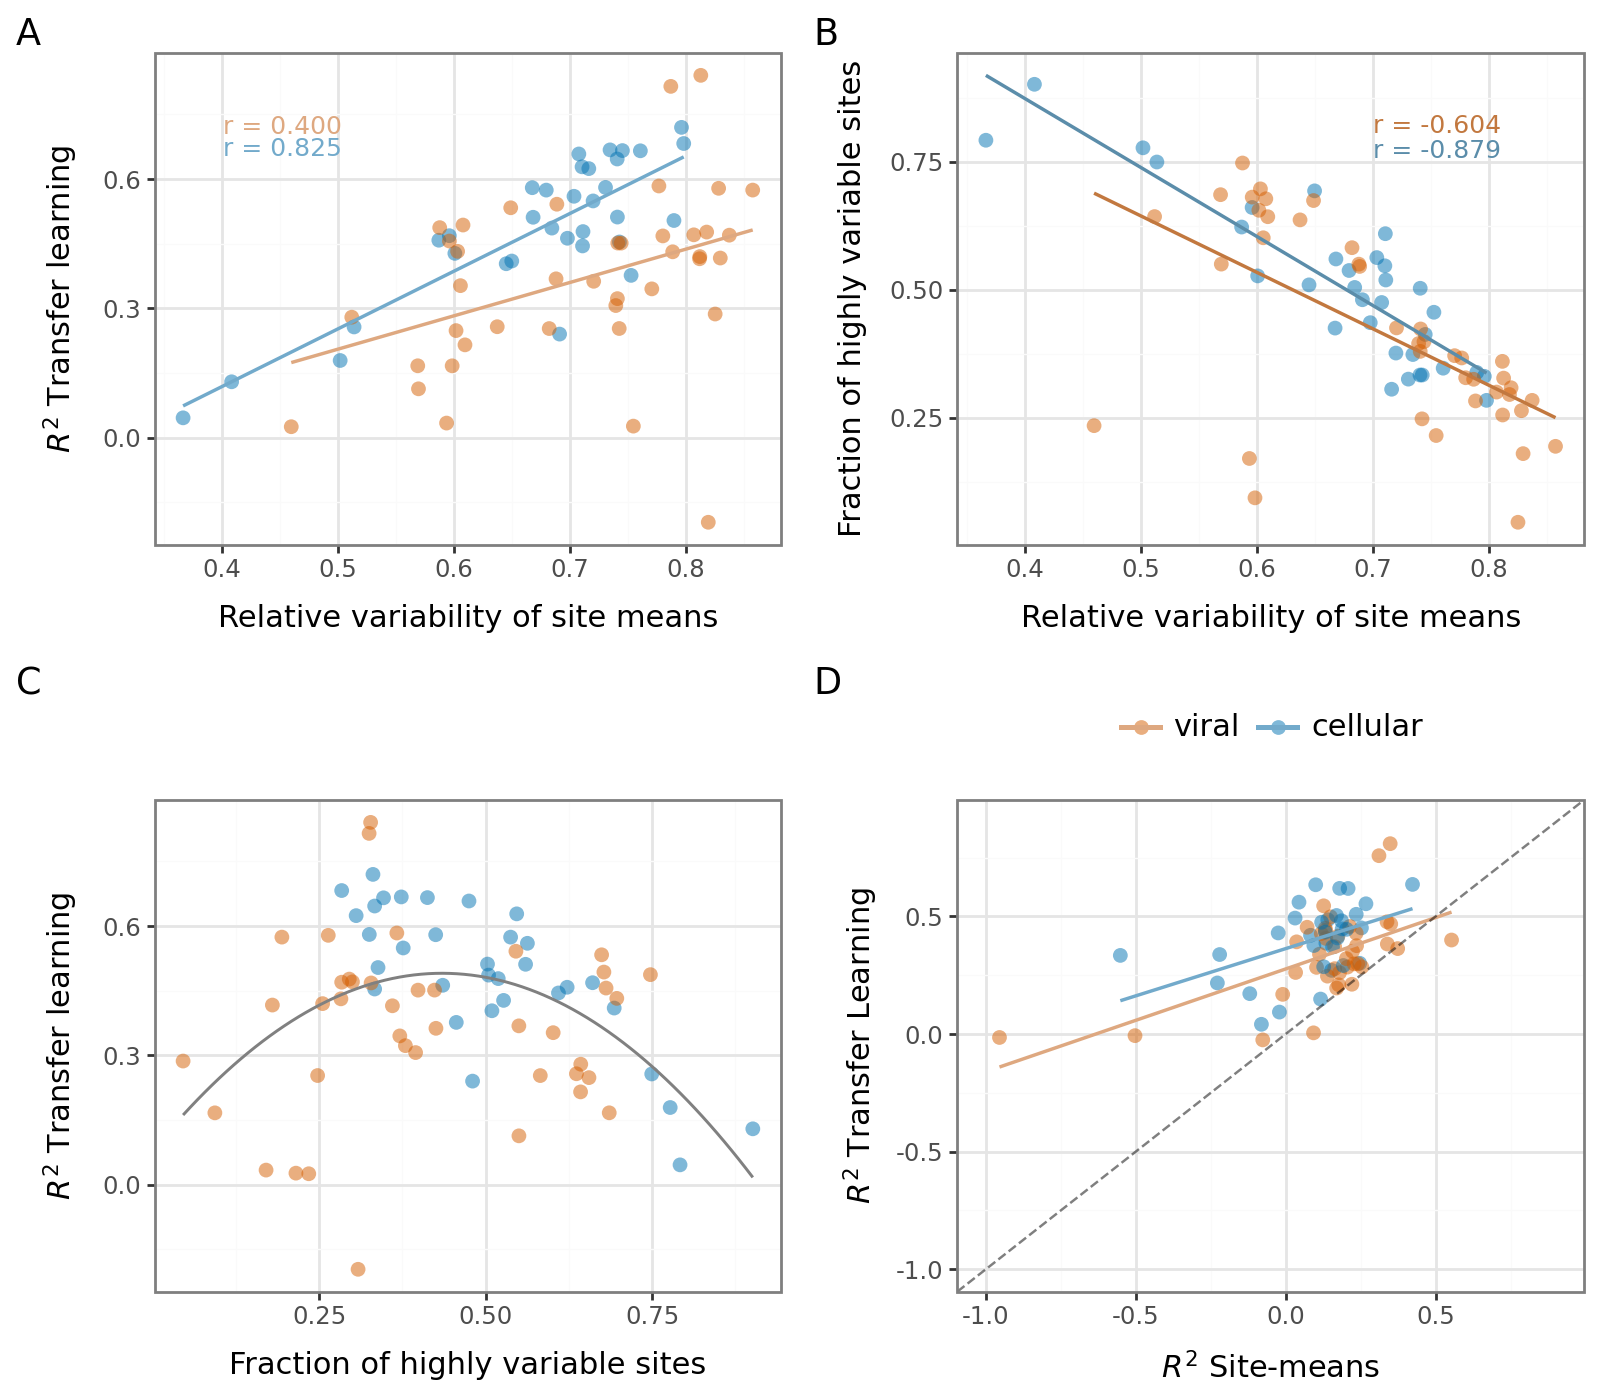

In [ ]:
comp = (p3 | p4) / (p5 | p6)
plot = comp + pln.theme(figure_size=(8, 7))
#plot.save(filename='../experiments/figures/comp3_site_variation4.png', dpi=600)
plot

# Stratified by Site

In [5]:
res = pd.read_csv('../experiments/compiled_results/res_lassoCV_esm2_650m_all_metrics.csv', index_col=0)

res['Source'] = pd.Categorical(res['Source'], categories=['viral', 'cellular'])
res

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,RVSM,FHVS,coverage,prot_length
0,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.593274,0.473718,0.637422,0.794904,0.486188,0.525113,0.717140,0.738094,444.8,0.684369,0.504399,0.949133,346
1,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.374695,0.604338,0.795778,0.647042,0.231793,0.647925,0.845461,0.504309,79.6,0.684369,0.504399,0.949133,346
2,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.556010,0.529118,0.665334,0.764524,0.468531,0.579832,0.733204,0.713379,590.4,0.596003,0.660592,0.948633,439
3,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.362078,0.643427,0.798541,0.642935,0.243568,0.700345,0.868268,0.545077,89.6,0.596003,0.660592,0.948633,439
4,ESM-2 650M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.360828,0.607812,0.800282,0.562654,0.256701,0.650875,0.857956,0.474479,533.0,0.513957,0.749431,0.918793,439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,ESM-2 650M,viral,SARS2_RBD_binding_Starr,Site Split,0.238382,0.650661,0.870498,0.389841,0.033222,0.719386,0.968608,0.200680,34.4,0.828026,0.263682,0.149332,1273
144,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.729695,0.409088,0.520078,0.843533,0.574433,0.506460,0.650963,0.751288,562.6,0.857385,0.194030,0.149175,1273
145,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Site Split,0.120889,0.818213,0.930678,0.289695,0.034882,0.875149,0.999084,0.193756,16.4,0.857385,0.194030,0.149175,1273
146,ESM-2 650M,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.666417,0.440333,0.577750,0.693423,-0.196764,0.541360,1.001461,0.610699,454.0,0.819106,0.308458,0.999751,201


In [6]:
def annotation_df(res, target, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['R2_score_test'].corr(res.query(q)[target], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df[target] = x
    ann_df['R2_score_test'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df

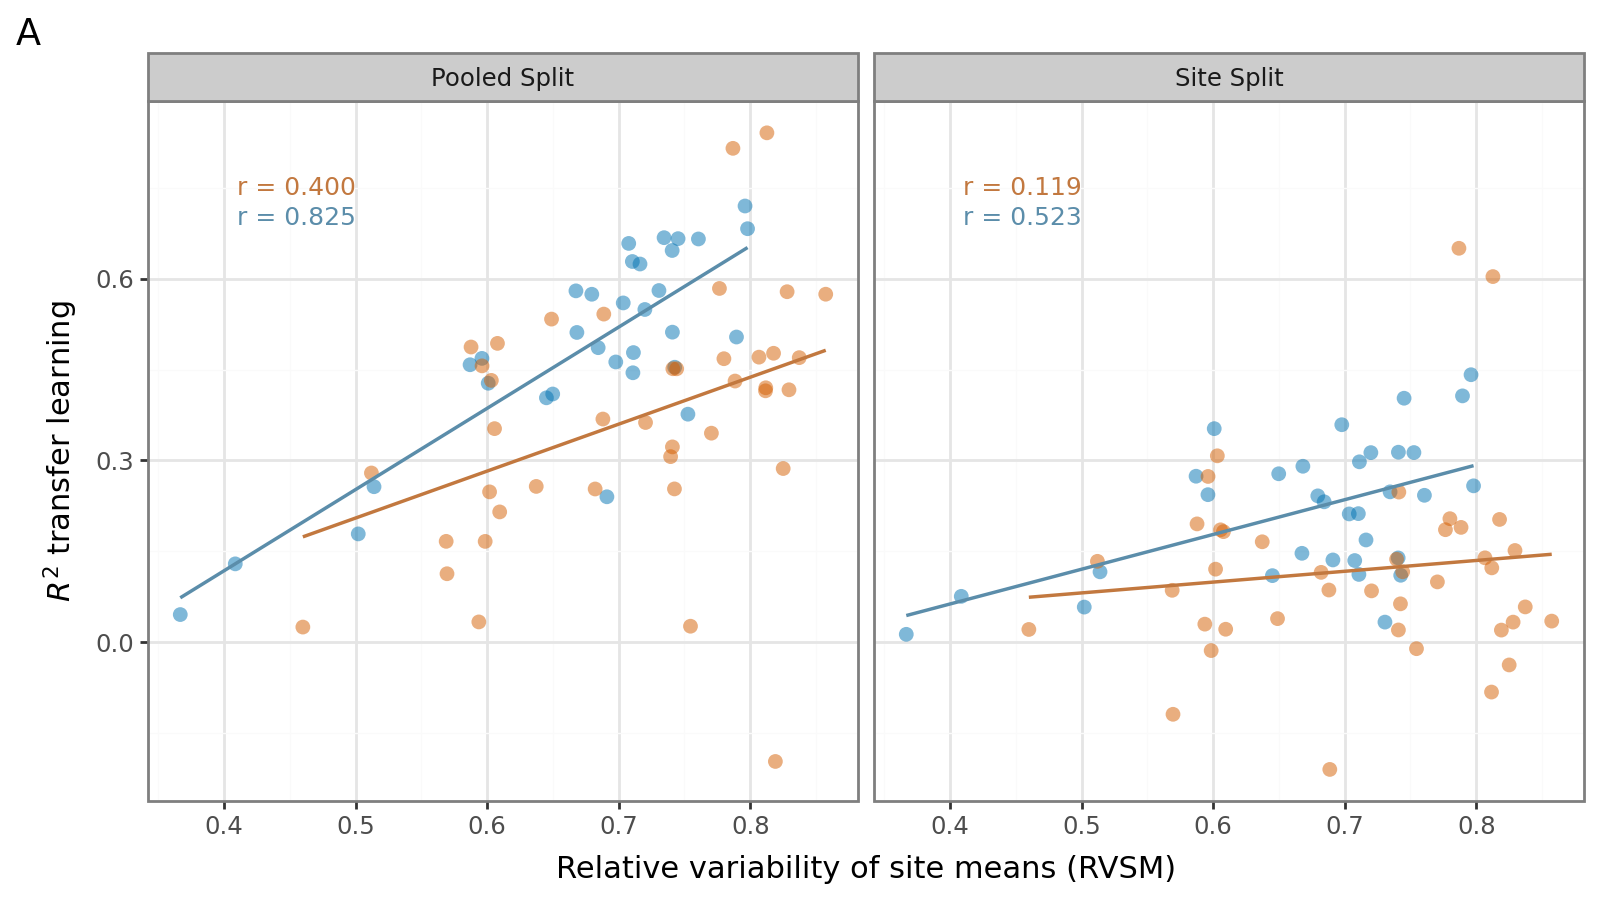

In [7]:
target = 'RVSM'
ann_df = annotation_df(res, target,  y=0.7)

RVSM = (
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='none', figure_size=(8, 4.5))
    + pln.labs(
         y='$R^2$ transfer learning',
        x= 'Relative variability of site means (RVSM)',
        tag='A')
    )
RVSM

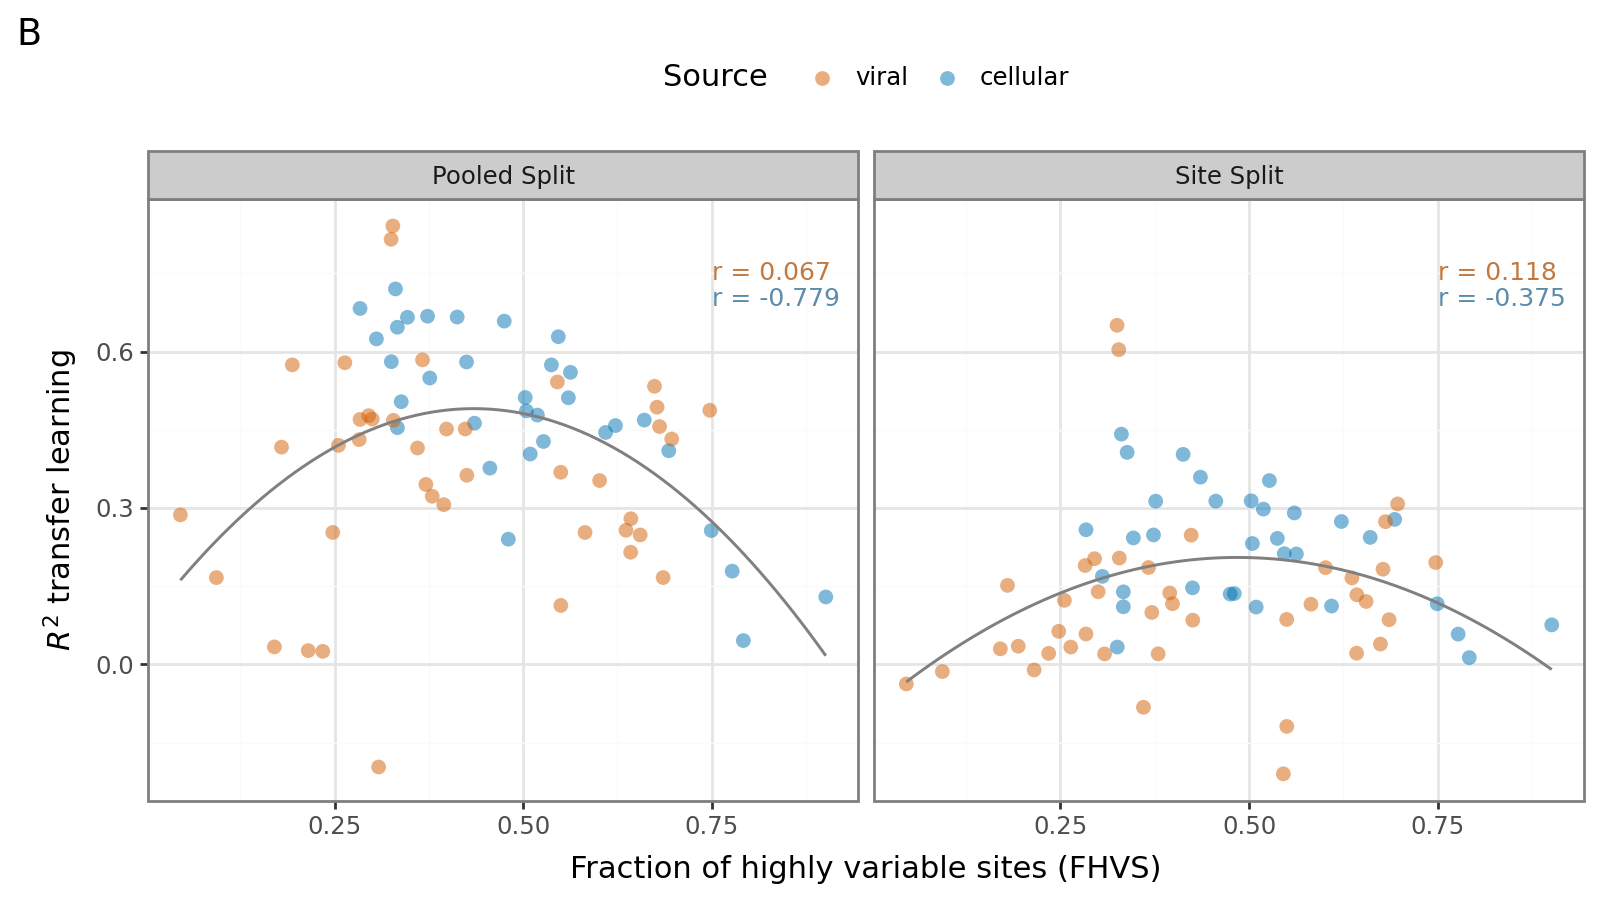

In [8]:
target = 'FHVS'
ann_df = annotation_df(res, target, x=0.75, y=0.7)

FHVS = (
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test'))
    + pln.geom_point(size=3, alpha=0.5, stroke=0, mapping=pln.aes(fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')

    + pln.geom_smooth(
        method='lm',
        formula='y ~ I(x*x) + x',
        se=False, alpha=1, size=0.6, color='grey'
      )

    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                size=9, ha="left", inherit_aes=False, show_legend=False)

    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
        y='$R^2$ transfer learning',
        x= 'Fraction of highly variable sites (FHVS)',
        tag='B')
    )

FHVS

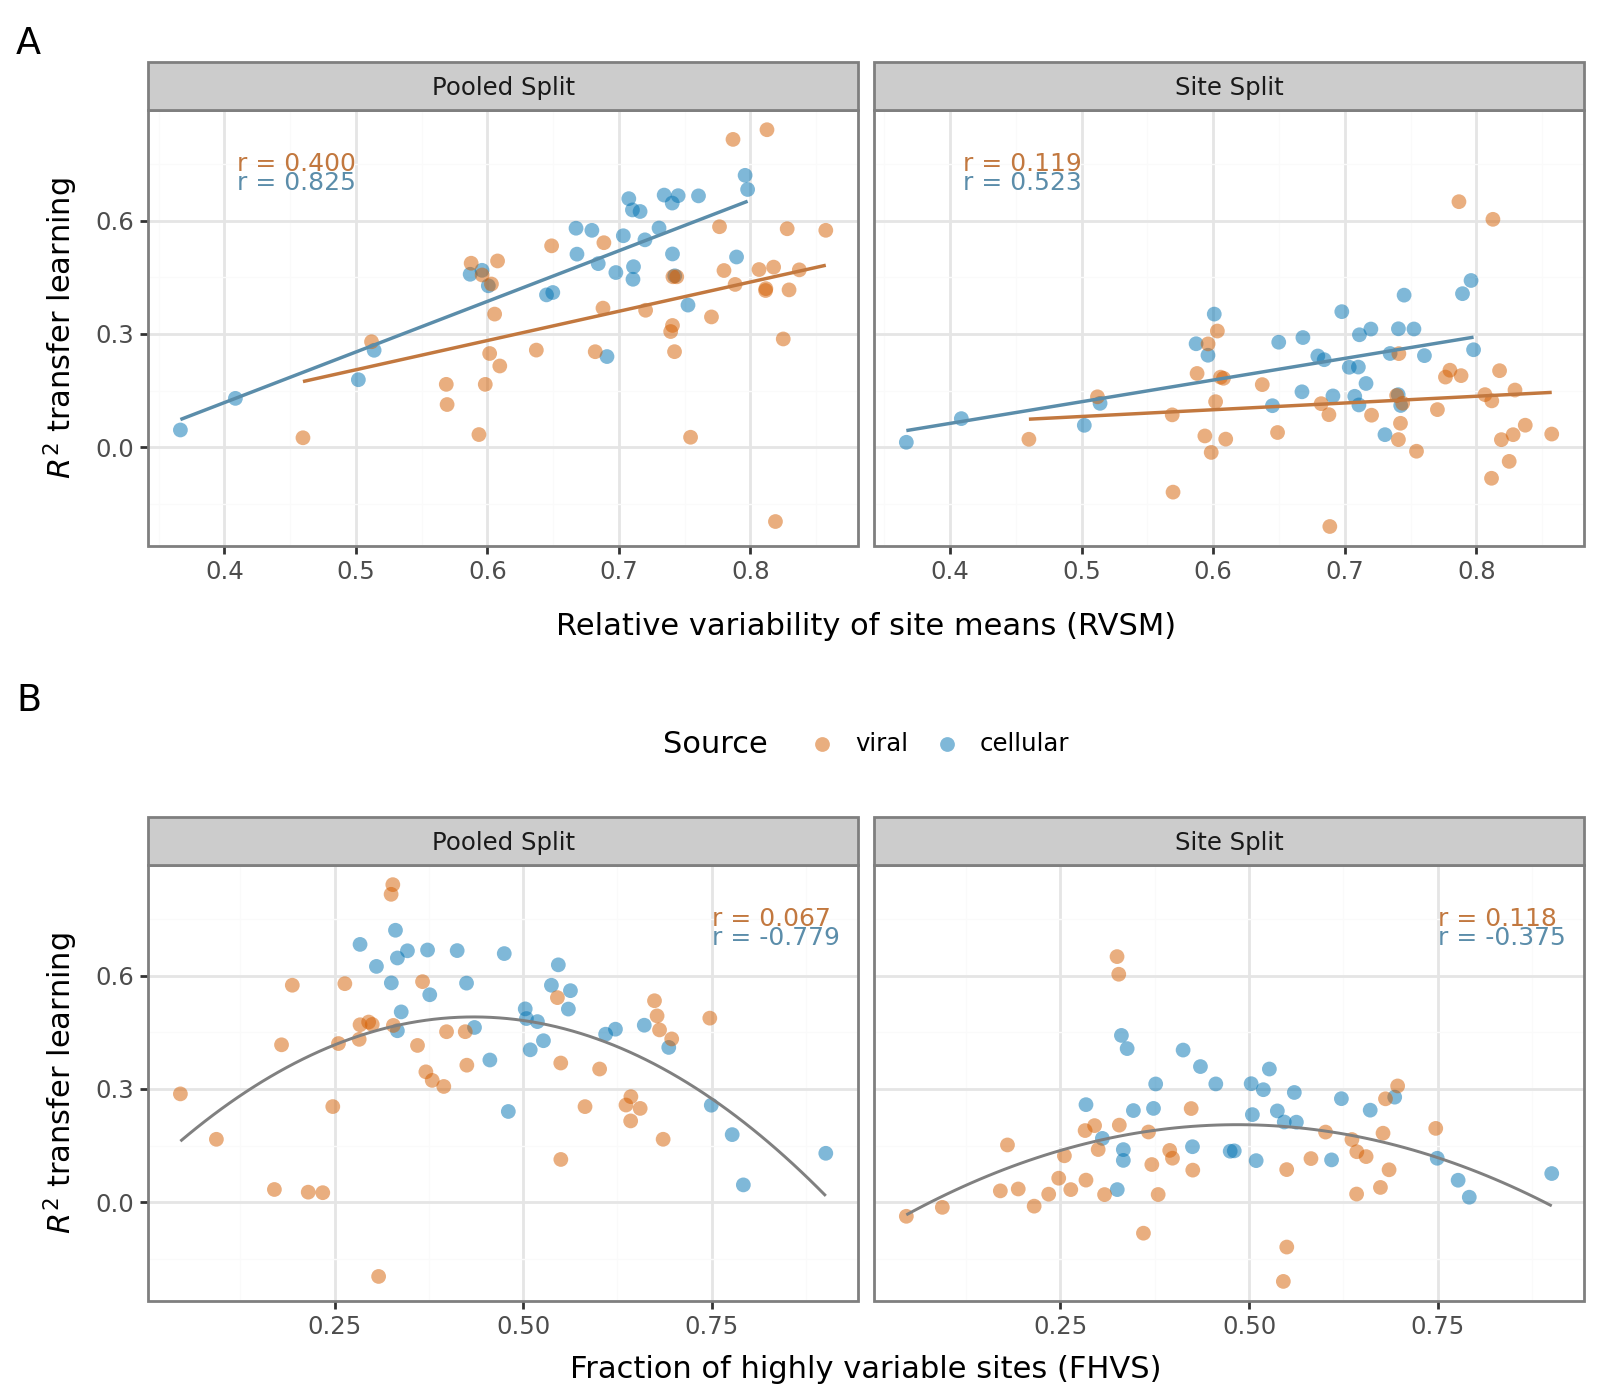

In [ ]:
comp = RVSM / FHVS
plot = comp + pln.theme(figure_size=(8, 7))
plot.save(filename='../experiments/figures/supp3_var_metrics_Site_Split.png', dpi=600)
plot